In [2]:
import os
import glob
import gdown 
import zipfile
import shutil

def download_data(save_folder, dataset_name="salaries"):
    dataset_list = ["salaries", "exams", "college", "cars", "mall"]
    assert dataset_name in dataset_list, f"Choose one of the available datasets: {dataset_list}"

    file_ids = {
        "college": "1vwfMpQ4ikAI91zn1bWxP_Iqz7DTFUA9F",
        "salaries": "1p-XtX29fgXT9CzBfpHm3t8r028gQPRhe",
        "exams": "1TYN_sRmauaDgNYgQ-0VSHVAJvLoxKx2R",
        "cars": "1Fi5IPdfEktnKyf3dyHmnh84a2jiXl33A",
        "mall": "1eGWJVRNmGjfaH0o3dczBbNe_-RrW0_Jm",
    }

    file_id = file_ids[dataset_name]
    zip_path = os.path.join(save_folder, f"{dataset_name}.zip")
    csv_path = os.path.join(save_folder, f"{dataset_name}.csv")

    os.makedirs(save_folder, exist_ok=True)

    if os.path.isfile(csv_path):
        print(f"{dataset_name}.csv is already downloaded.")
        return

    print(f"⬇️ Downloading dataset: {dataset_name}...")

    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, zip_path, quiet=False)

    if not os.path.exists(zip_path):
        print("Error: ZIP file was not downloaded!")
        return
    if not zipfile.is_zipfile(zip_path):
        print("Error: The downloaded file is not a valid ZIP! Check the Google Drive link.")
        return

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(save_folder)

    os.remove(zip_path)

    extracted_files = glob.glob(os.path.join(save_folder, "*"))
    
    if not extracted_files:
        print("Error: No files were extracted! Check if the ZIP contains a subfolder.")
        return

    if len(extracted_files) == 1 and os.path.isdir(extracted_files[0]):
        extracted_files = glob.glob(os.path.join(extracted_files[0], "*"))

    csv_files = [f for f in extracted_files if f.endswith(".csv")]

    if not csv_files:
        print("Error: No CSV files found after extraction!")
        return

    latest_csv = max(csv_files, key=os.path.getctime)
    shutil.move(latest_csv, csv_path)

    print(f" {dataset_name}.csv successfully downloaded and saved.")

download_data("datasets", "college")
download_data("datasets", "exams")
download_data("datasets", "cars")
download_data("datasets", "mall")

⬇️ Downloading dataset: college...


Downloading...
From: https://drive.google.com/uc?id=1vwfMpQ4ikAI91zn1bWxP_Iqz7DTFUA9F
To: c:\Users\user\Desktop\ml2\datasets\college.zip
100%|██████████| 32.4k/32.4k [00:00<00:00, 450kB/s]


 college.csv successfully downloaded and saved.
⬇️ Downloading dataset: exams...


Downloading...
From: https://drive.google.com/uc?id=1TYN_sRmauaDgNYgQ-0VSHVAJvLoxKx2R
To: c:\Users\user\Desktop\ml2\datasets\exams.zip
100%|██████████| 8.91k/8.91k [00:00<00:00, 539kB/s]


 exams.csv successfully downloaded and saved.
⬇️ Downloading dataset: cars...


Downloading...
From: https://drive.google.com/uc?id=1Fi5IPdfEktnKyf3dyHmnh84a2jiXl33A
To: c:\Users\user\Desktop\ml2\datasets\cars.zip
100%|██████████| 4.78k/4.78k [00:00<00:00, 789kB/s]


 cars.csv successfully downloaded and saved.
⬇️ Downloading dataset: mall...


Downloading...
From: https://drive.google.com/uc?id=1eGWJVRNmGjfaH0o3dczBbNe_-RrW0_Jm
To: c:\Users\user\Desktop\ml2\datasets\mall.zip
100%|██████████| 1.58k/1.58k [00:00<00:00, 1.59MB/s]

 mall.csv successfully downloaded and saved.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("datasets/mall.csv")

In [7]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
features = df.columns

In [9]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

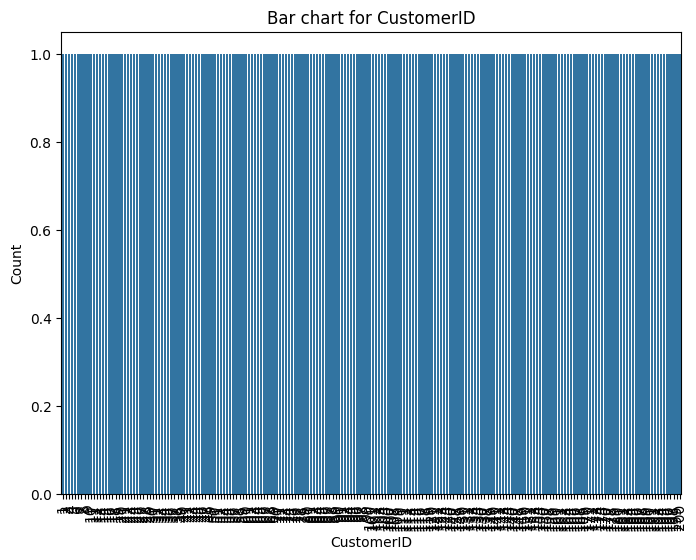

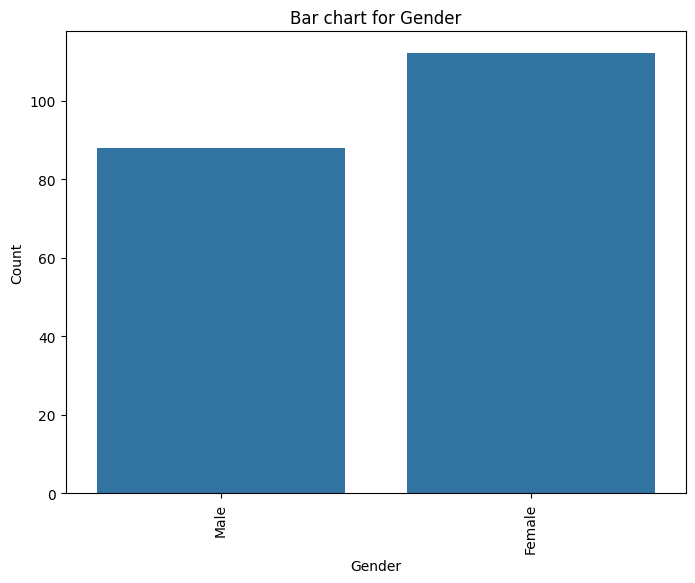

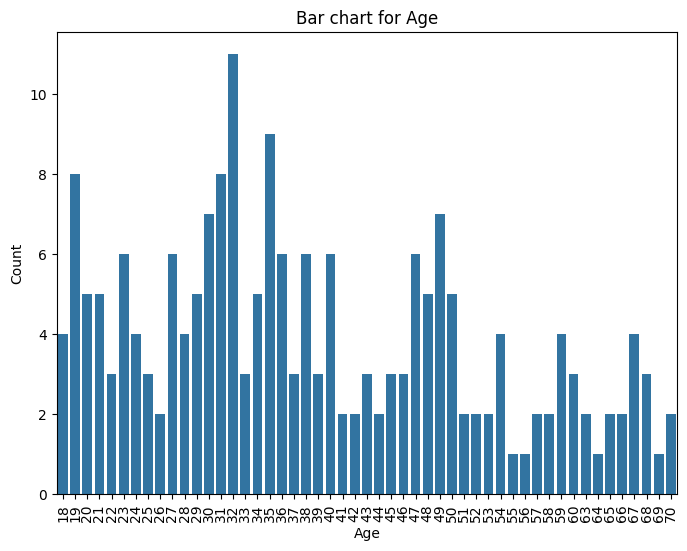

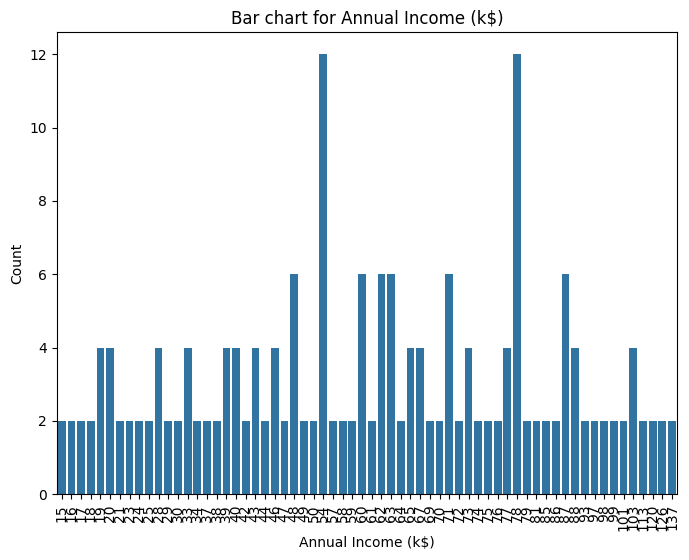

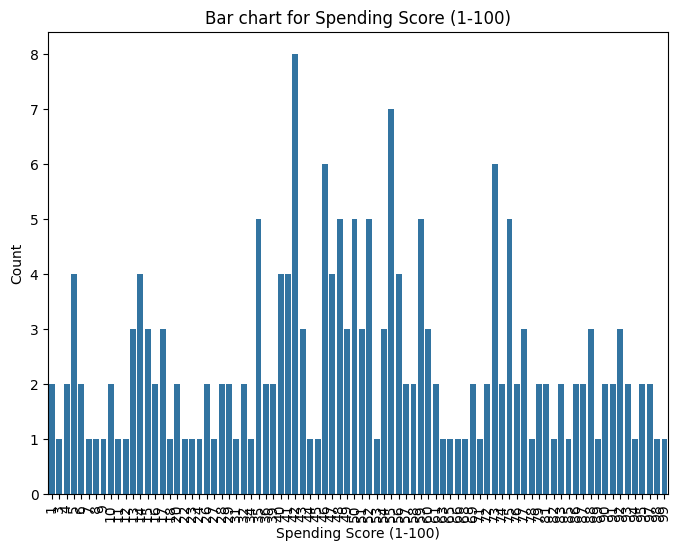

In [11]:
for feature in features:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=feature)
    plt.title(f'Bar chart for {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=90)  # Rotate labels if feature names are long
    plt.show()

In [13]:
from sklearn.model_selection import train_test_split

In [15]:
X = df.drop('Age', axis=1)
y = df['Age']


In [16]:
# First split: 70% train, 30% remaining (validation + test)
X_train, X_remaining, y_train, y_remaining = train_test_split(X, y, test_size=0.3, random_state=42)


In [17]:
# Second split: 50% validation, 50% test (of the 30% remaining)
X_val, X_test, y_val, y_test = train_test_split(X_remaining, y_remaining, test_size=0.5, random_state=42)


In [18]:
print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Training set: (140, 4)
Validation set: (30, 4)
Test set: (30, 4)


In [19]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [24]:
# Display column names of your dataset
print("Columns in your dataset:", df.columns)
numerical_columns = ['Age', 'Annual Income (k$)']  # Replace with actual numerical columns in your dataset
categorical_columns = ['Gender']  # Replace with actual categorical columns in your dataset
# Before scaling or encoding: Print the original data
print("\n--- Original DataFrame ---")
print(df)
# Using StandardScaler for numerical features
scaler = StandardScaler()
scaled_numerical = scaler.fit_transform(df[numerical_columns])
# Using OneHotEncoder for categorical features
encoder = OneHotEncoder(sparse_output=False)
encoded_categorical = encoder.fit_transform(df[categorical_columns])
# Display before and after transformations
print("\n--- Before and After Transformation ---")
# Before transformation (numerical values)
print("\nBefore StandardScaler (numerical values):")
print(df[numerical_columns])

# After StandardScaler
print("\nAfter StandardScaler (numerical values):")
print(scaled_numerical)

# Before transformation (categorical values)
print("\nBefore OneHotEncoder (categorical values):")
print(df[categorical_columns])

# After OneHotEncoder
print("\nAfter OneHotEncoder (categorical values):")
print(encoded_categorical)

# Convert the scaled data and encoded data back into DataFrames for better readability
scaled_df = pd.DataFrame(scaled_numerical, columns=numerical_columns)
encoded_df = pd.DataFrame(encoded_categorical, columns=encoder.get_feature_names_out(categorical_columns))

# Combine them back together
final_df = pd.concat([scaled_df, encoded_df], axis=1)

print("\nFinal DataFrame after Scaling and Encoding:")
print(final_df)

Columns in your dataset: Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

--- Original DataFrame ---
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30

In [25]:
import csv

# Define new datapoints (for example, we assume Age, Annual Income, Gender)
new_data = [
    ["Age", "Annual Income (k$)", "Gender"],  # Column headers
    [28, 55000, "Male"],  # Data point 1
    [35, 75000, "Female"],  # Data point 2
    [40, 90000, "Male"]  # Data point 3
]

# Write to a CSV file
with open('new_data.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(new_data)

print("New data points saved to 'new_data.csv'.")


New data points saved to 'new_data.csv'.
